In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, pointbiserialr, chi2_contingency

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
df = pd.read_csv(
    "diabetic_data.csv",
    na_values=['?'],
    low_memory=False
)

print(f"Initial dataset shape: {df.shape}")
df.head()

Initial dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.info()

object_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nNumber of categorical variables: {len(object_cols)}")
print(f"Number of numerical variables: {len(numeric_cols)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

این دیتاست شامل ۱۰۱,۷۶۶ رکورد و ۵۰ متغیر است که به دو دسته‌ی اصلی تقسیم می‌شوند:

متغیرهای عددی: شامل مدت بستری، تعداد آزمایش‌ها، تعداد داروها، تعداد مراجعات قبلی به اورژانس و مطب و بستری و تعداد تشخیص‌ها.

متغیرهای دسته‌ای: شامل اطلاعات جمعیت‌شناختی مثل نژاد، جنسیت و گروه سنی، اطلاعات بستری مثل نوع پذیرش و منبع پذیرش و وضعیت ترخیص، تشخیص‌های اولیه و ثانویه و ثالثیه، نتایج آزمایش‌ها مثل قند خون و هموگلوبین ای وان سی، و ۲۳ ستون مربوط به داروهای دیابت که وضعیت مصرف هر دارو را نشان می‌دهند.

در ادامه‌ی کار، ابتدا مقادیر گمشده را با آستانه‌ی ۸۰ درصد بررسی می‌کنیم و ستون‌های با گمشده‌ی بیش از این مقدار را حذف می‌کنیم. سپس رکوردهای تکراری و داده‌های پرت را بررسی کرده و در نهایت با تحلیل دوبه‌دوی متغیرها، همبستگی‌ها را ارزیابی می‌کنیم.

In [8]:
missing = pd.DataFrame({
    'missing number': df.isnull().sum(),
    'missing percent': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing['missing number'] > 0].sort_values('missing percent', ascending=False)

missing['Decision'] = np.where(
    missing['missing percent'] > 80,
    'Drop',
    'Hold'
)

missing

,missing number,missing percent,Decision
weight,98569,96.86,Drop
max_glu_serum,96420,94.75,Drop
A1Cresult,84748,83.28,Drop
medical_specialty,49949,49.08,Hold
payer_code,40256,39.56,Hold
race,2273,2.23,Hold
diag_3,1423,1.40,Hold
diag_2,358,0.35,Hold
diag_1,21,0.02,Hold


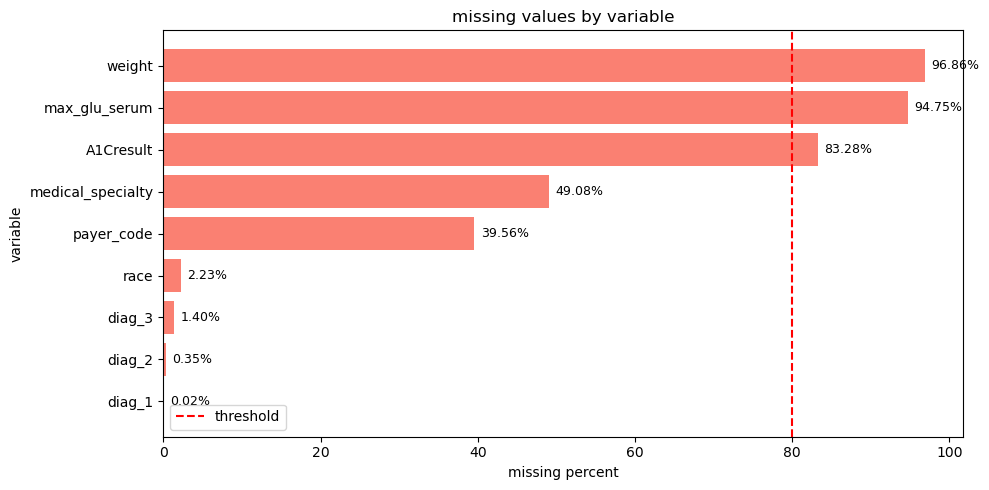

In [10]:
plt.figure(figsize=(10, 5))
bars = plt.barh(missing.index, missing['missing percent'], color='salmon')
plt.axvline(x=80, color='red', linestyle='--', linewidth=1.5, label='threshold')

for bar, val in zip(bars, missing['missing percent']):
    plt.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}%', va='center', fontsize=9)

plt.xlabel('missing percent')
plt.ylabel('variable')
plt.title('missing values by variable')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

آستانه‌ی ۸۰ درصد را برای حذف در نظر گرفتیم. بر اساس جدول و نمودار بالا:

ستون وزن بیمار با حدود ۹۷ درصد گمشده به دلیل عبور از آستانه حذف می‌شود.

ستون کد پرداخت‌کننده با حدود ۴۰ درصد گمشده از آستانه عبور نمی‌کند، اما چون ارتباط منطقی با هدف ندارد و کیفیت داده‌اش پایین است، در ادامه همراه با ستون وزن بیمار حذف خواهد شد.

دو ستون نتیجه‌ی هموگلوبین ای وان سی و قند خون ناشتا، درصد گمشده‌ی بسیار بالایی دارند اما این گمشده بودن خودش معنادار است، چون نشان می‌دهد تست برای بیمار انجام نشده. اما با توجه به نظر گروه این دو متغیر حذف میکنیم.

ستون تخصص پزشکی با حدود ۴۹ درصد گمشده، در ادامه با لیبل گمشده جایگذاری می‌شود

سه ستون تشخیص با درصد گمشده‌ی کم، در ادامه با برچسب گمشده جایگذاری شده و سپس گروه‌بندی می‌شوند.


In [13]:
Deleted_columns = ['weight', 'payer_code', 'max_glu_serum', 'A1Cresult' ]

df_clean = df.drop(columns=Deleted_columns).copy()

print(f"Dataset shape after dropping columns: {df_clean.shape}")
print(f"Deleted_columns: {Deleted_columns}")

Dataset shape after dropping columns: (101766, 46)
Deleted_columns: ['weight', 'payer_code', 'max_glu_serum', 'A1Cresult']


In [15]:
patient_id = df_clean['patient_nbr'].copy()
patient_id.to_csv('patient_ids_for_split.csv', index=False)

df_clean = df_clean.drop(columns=['encounter_id', 'patient_nbr'])

print(f"Dataset shape after dropping IDs: {df_clean.shape}")

Dataset shape after dropping IDs: (101766, 44)



ستون شناسه‌ی هر بستری چون یکتاست، هیچ اطلاعاتی به مدل اضافه نمی‌کند و حذف شد.

ستون شناسه‌ی بیمار به‌عنوان یک متغیر توضیحی حذف شد، اما قبل از حذف در فایل جداگانه‌ای ذخیره شد. دلیل این کار این است که در دیتاست اصلی، برخی بیماران چندین بار بستری شده‌اند. اگر تقسیم آموزش و آزمون به‌صورت تصادفی انجام شود، ممکن است یک بیمار هم در مجموعه‌ی آموزش و هم در مجموعه‌ی آزمون قرار بگیرد و این باعث نشت داده می‌شود

In [18]:
record_counts = df['patient_nbr'].value_counts()
unique_count = df['patient_nbr'].nunique()
duplicate_count = (record_counts > 1).sum()

print(f"Total records: {len(df):,}")
print(f"Unique patients: {unique_count:,}")
print(f"Patients with more than one admission: {duplicate_count:,}")
print(f"Maximum admissions for a single patient: {record_counts.max()}")

Total records: 101,766
Unique patients: 71,518
Patients with more than one admission: 16,773
Maximum admissions for a single patient: 40


بخشی از رکوردها مربوط به بیمارانی است که چندین بار بستری شده‌اند و باعث می‌شود تعداد بیماران یکتا کمتر از تعداد کل رکوردها باشد.

تصمیم: تمام رکوردها نگه داشته می‌شوند تا حجم داده برای آموزش کافی باشد

In [21]:
duplicate_count = df_clean.duplicated().sum()
print(f"Number of completely duplicate records: {duplicate_count}")

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f"Dataset shape after removing duplicates: {df_clean.shape}")

Number of completely duplicate records: 0


رکوردهای کاملاً تکراری در دیتاست وجود ندارند، چون هر رکورد حداقل از نظر مدت بستری یا تعداد داروها با رکوردهای دیگر متفاوت است. بنابراین تصمیم خاصی برای حذف گرفته نمی‌شود.

In [24]:
print("Three-class target distribution:")
print(df_clean['readmitted'].value_counts())
print()
print("Percentage of each class:")
print((df_clean['readmitted'].value_counts(normalize=True) * 100).round(2))

Three-class target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Percentage of each class:
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


تارگت اصلی سه کلاس دارد: عدم بازگشت، بازگشت پس از ۳۰ روز و بازگشت زیر ۳۰ روز.

کلاس بازگشت زیر ۳۰ روز که هدف اصلی این پروژه است، تنها حدود ۱۱ درصد رکوردها را تشکیل می‌دهد. این عدم توازن شدید بین کلاس‌ها باعث می‌شود معیار دقت به‌تنهایی گمراه‌کننده باشد و باید از معیارهای دیگر مثل recall و F1 و ماتریس درهم‌ریختگی استفاده شود.

تصمیم: تارگت به حالت باینری تبدیل می‌شود. کلاس بازگشت زیر ۳۰ روز به‌عنوان مثبت و دو کلاس دیگر به‌عنوان منفی در نظر گرفته می‌شوند.

In [27]:
df_clean['readmitted_binary'] = np.where(
    df_clean['readmitted'].eq('<30'),
    'Yes',
    'No'
)

print("Binary target distribution:")
print(df_clean['readmitted_binary'].value_counts())
print()
print("Percentage of each class:")
print((df_clean['readmitted_binary'].value_counts(normalize=True) * 100).round(2))

Binary target distribution:
readmitted_binary
No     90409
Yes    11357
Name: count, dtype: int64

Percentage of each class:
readmitted_binary
No     88.84
Yes    11.16
Name: proportion, dtype: float64


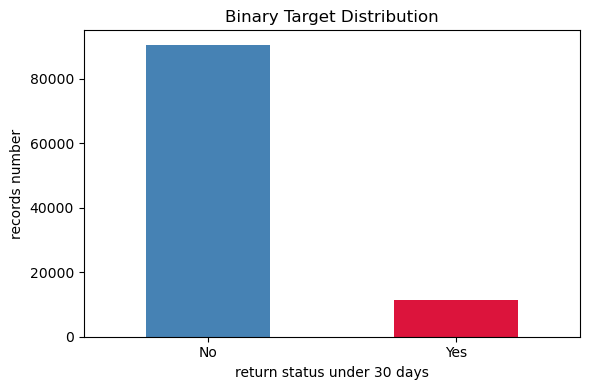

In [29]:
plt.figure(figsize=(6, 4))
df_clean['readmitted_binary'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'crimson']
)
plt.title('Binary Target Distribution')
plt.xlabel('return status under 30 days')
plt.ylabel('records number')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

تارگت باینری ساخته شد. کلاس مثبت که همان بازگشت زیر ۳۰ روز است، حدود ۱۱ درصد داده را تشکیل می‌دهد و کلاس منفی حدود ۸۹ درصد. این نسبت عدم توازن حدود یک به هشت را نشان می‌دهد.

معیارهای پیشنهادی برای ارزیابی مدل در ادامه‌ی پروژه:

حساسیت یا همان recall برای کلاس مثبت که مهم‌ترین معیار است چون از دست دادن یک بیمار در معرض خطر، هزینه‌ی بالینی دارد.

معیار F1 برای کلاس مثبت.

ماتریس درهم‌ریختگی برای دیدن خطاهای دسته‌بندی.

نرخ منفی کاذب.

استفاده از وزن کلاس یا روش‌های بازنمونه‌گیری برای متوازن‌سازی.

In [32]:
death_hospice_codes = [11, 13, 14, 19, 20, 21]

before = len(df_clean)
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(death_hospice_codes)].copy()
after = len(df_clean)

print(f"Number of death or hospice records: {before - after}")
print(f"Dataset shape after removal: {df_clean.shape}")

Number of death or hospice records: 2423
Dataset shape after removal: (99343, 45)


رکوردهایی که وضعیت ترخیص آن‌ها فوت یا انتقال به هوسپیس است، حذف شدند چون این بیماران امکان بازگشت به بیمارستان را ندارند و نگه‌داشتن آن‌ها می‌تواند نتیجه‌ی مدل را مخدوش کند

In [35]:
df_clean = df_clean.dropna(subset=['race']).copy()
print(f" after remove the missing race: {df_clean.shape}")

df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid'].copy()
print(f"After removing invalid gender: {df_clean.shape}")

 after remove the missing race: (97109, 45)
After removing invalid gender: (97108, 45)


رکوردهایی که نژادشان گمشده بود حذف شدند، چون درصد گمشده‌شان کم است و نمی‌توان با اطمینان جایگذاری کرد.

رکوردهای با جنسیت نامعتبر هم که تعداد بسیار کمی داشتند، حذف شدند.

In [38]:
categorical_columns = ['race', 'gender', 'age', 'admission_type_id',
                    'discharge_disposition_id', 'admission_source_id',
                    'medical_specialty']

for col in categorical_columns:
    print(f"=== {col} ===")
    print(df_clean[col].value_counts(dropna=False).head(15))
    print()

=== race ===
race
Caucasian          74220
AfricanAmerican    18772
Hispanic            2017
Other               1471
Asian                628
Name: count, dtype: int64

=== gender ===
gender
Female    52336
Male      44772
Name: count, dtype: int64

=== age ===
age
[70-80)     24743
[60-70)     21572
[50-60)     16701
[80-90)     16049
[40-50)      9389
[30-40)      3688
[90-100)     2522
[20-30)      1603
[10-20)       682
[0-10)        159
Name: count, dtype: int64

=== admission_type_id ===
admission_type_id
1    51306
3    18311
2    17445
6     5141
5     4561
8      317
7       17
4       10
Name: count, dtype: int64

=== discharge_disposition_id ===
discharge_disposition_id
1     58767
3     13614
6     12698
18     3673
2      2061
22     1981
5      1143
25      973
4       765
7       611
23      406
28      138
8       107
15       63
24       48
Name: count, dtype: int64

=== admission_source_id ===
admission_source_id
7     55012
1     28461
17     6489
4      2923
6     

بررسی متغیرهای دسته‌ای نشان می‌دهد که بعضی از متغیرها مقادیر نادر زیادی دارند. مثلاً در ستون نوع پذیرش، کدهای ۴ و ۷ و ۸ تعداد بسیار کمی دارند. در ستون منبع پذیرش هم کدهای متعددی با فراوانی بسیار کم وجود دارد.

در ستون وضعیت ترخیص، کد ۱۸ به‌معنای نامشخص است و در ادامه با لیبل مشخص جایگذاری می‌شود.

در ادامه، متغیرهای نادر را در یک دسته‌ی مشترک با عنوان سایر گروه‌بندی می‌کنیم تا مدل دچار بیش‌برازش روی دسته‌های کوچک نشود.

In [41]:
rare_admission_codes = [4, 7, 8]

df_clean['admission_type_id'] = df_clean['admission_type_id'].apply(
    lambda x: 'Other' if x in rare_admission_codes else str(x)
)

print(df_clean['admission_type_id'].value_counts())


rare_source_codes = [8, 10, 11, 13, 14, 22, 25]

df_clean['admission_source_id'] = df_clean['admission_source_id'].apply(
    lambda x: 'Other' if x in rare_source_codes else str(x)
)
print(df_clean['admission_source_id'].value_counts())

admission_type_id
1        51306
3        18311
2        17445
6         5141
5         4561
Other      344
Name: count, dtype: int64
admission_source_id
7        55012
1        28461
17        6489
4         2923
6         1964
2         1021
5          800
3          185
20         158
9           54
Other       41
Name: count, dtype: int64


In [43]:
df_clean['discharge_disposition_id'] = (
    df_clean['discharge_disposition_id'].astype(str).replace('18', 'Unknown')
)

print(df_clean['discharge_disposition_id'].value_counts().head(10))

discharge_disposition_id
1          58767
3          13614
6          12698
Unknown     3673
2           2061
22          1981
5           1143
25           973
4            765
7            611
Name: count, dtype: int64


نوع پذیرش، منبع پذیرش و وضعیت ترخیص همه گروه‌بندی شدند. مقادیر نادر در دسته‌ی سایر قرار گرفتند و مقدار نامشخص در وضعیت ترخیص با لیبل گمشده مشخص شد. این کار باعث می‌شود مدل روی دسته‌های کوچک دچار بیش‌برازش نشود.

In [46]:
age_mapping = {
    '[0-10)': '<30', '[10-20)': '<30', '[20-30)': '<30',
    '[30-40)': '[30,60)', '[40-50)': '[30,60)', '[50-60)': '[30,60)',
    '[60-70)': '[60,100)', '[70-80)': '[60,100)',
    '[80-90)': '[60,100)', '[90-100)': '[60,100)'
}

df_clean['age_group'] = df_clean['age'].map(age_mapping)
df_clean = df_clean.drop(columns=['age'])

print(df_clean['age_group'].value_counts())

age_group
[60,100)    64886
[30,60)     29778
<30          2444
Name: count, dtype: int64


متغیر سن با ده بازه‌ی ده‌ساله در دیتاست اصلی وجود دارد که برای مدل‌سازی بسیار ریز است. این متغیر به سه گروه کلی تبدیل شد:

گروه زیر ۳۰ سال، گروه ۳۰ تا ۶۰ سال و گروه بالای ۶۰ سال. این گروه‌بندی با توزیع سنی بیماران دیابتی سازگار است و اکثر بیماران در گروه بالای ۶۰ سال قرار می‌گیرند.

In [49]:
def diagnosis_group(code):
    if pd.isna(code) or str(code) == 'Missing':
        return 'Missing'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        num_val = float(code)
    except ValueError:
        return 'Other'
    if 250 <= num_val < 251: return 'Diabetes'
    if (390 <= num_val <= 459) or num_val == 785: return 'Circulatory'
    if (460 <= num_val <= 519) or num_val == 786: return 'Respiratory'
    if (520 <= num_val <= 579) or num_val == 787: return 'Digestive'
    if (580 <= num_val <= 629) or num_val == 788: return 'Genitourinary'
    if 140 <= num_val <= 239: return 'Neoplasms'
    if 710 <= num_val <= 739: return 'Musculoskeletal'
    if 800 <= num_val <= 999: return 'Injury'
    return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[col + '_group'] = df_clean[col].apply(diagnosis_group)

df_clean = df_clean.drop(columns=['diag_1', 'diag_2', 'diag_3'])
print(f"Dataset shape after grouping diagnoses: {df_clean.shape}")

Dataset shape after grouping diagnoses: (97108, 45)


کدهای تشخیص بین‌المللی بیماری‌ها به‌صورت عدد خام برای مدل بی‌معنا هستند. این کدها به ده گروه بالینی اصلی تبدیل شدند:

گردش خون، تنفسی، گوارشی، ادراری تناسلی، دیابت، سرطان، استخوان و عضله، آسیب و مسمومیت، سایر و گمشده.

این گروه‌بندی بر اساس طبقه‌بندی استاندارد کدهای بین‌المللی انجام شد و به مدل اجازه می‌دهد الگوهای بالینی را بهتر تشخیص دهد.

In [52]:
drugs_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

drugs_summary = []
for col in drugs_columns:
    value_counts = df_clean[col].value_counts()
    total = len(df_clean)
    drugs_summary.append({
        'drug': col,
        'unique_values_count': df_clean[col].nunique(),
        'max_frequency_percent': round(value_counts.iloc[0] / total * 100, 2),
        'dominant_value': value_counts.index[0]
    })


drugs_summary_df = pd.DataFrame(drugs_summary).sort_values(
    'max_frequency_percent', ascending=False
)

drugs_summary_df

,drug,unique_values_count,max_frequency_percent,dominant_value
22,metformin-pioglitazone,2,100.00,No
21,metformin-rosiglitazone,1,100.00,No
20,glimepiride-pioglitazone,2,100.00,No
5,acetohexamide,2,100.00,No
16,citoglipton,1,100.00,No
15,examide,1,100.00,No
13,troglitazone,2,100.00,No
19,glipizide-metformin,2,99.99,No
8,tolbutamide,2,99.98,No
12,miglitol,4,99.96,No


In [54]:
threshold=99.5
fixed_columns = []
for col in df_clean.select_dtypes(include='object').columns:
    max_percent = df_clean[col].value_counts(normalize=True).iloc[0] * 100
    if max_percent >= threshold:
        fixed_columns.append({
            'variable': col,
            'dominant_value': df_clean[col].value_counts().index[0],
            'dominant_percent': round(max_percent, 2),
            'unique_values_count': df_clean[col].nunique()
        })

constant_table = pd.DataFrame(fixed_columns).sort_values('dominant_percent', ascending=False)
constant_table

,variable,dominant_value,dominant_percent,unique_values_count
1,acetohexamide,No,100.00,2
5,troglitazone,No,100.00,2
7,examide,No,100.00,1
8,citoglipton,No,100.00,1
10,glimepiride-pioglitazone,No,100.00,2
11,metformin-rosiglitazone,No,100.00,1
12,metformin-pioglitazone,No,100.00,2
9,glipizide-metformin,No,99.99,2
2,tolbutamide,No,99.98,2
4,miglitol,No,99.96,4


In [56]:
constant_cols_to_drop = constant_table['variable'].tolist()

df_clean = df_clean.drop(columns=constant_cols_to_drop)

print(f"Number of columns dropped due to being constant: {len(constant_cols_to_drop)}")
print(f"Dropped list: {constant_cols_to_drop}")
print(f"Dataset shape after dropping: {df_clean.shape}")

Number of columns dropped due to being constant: 13
Dropped list: ['acetohexamide', 'troglitazone', 'examide', 'citoglipton', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'glipizide-metformin', 'tolbutamide', 'miglitol', 'tolazamide', 'chlorpropamide', 'acarbose']
Dataset shape after dropping: (97108, 32)


بررسی ستون‌های دارویی نشان داد که تعداد قابل توجهی از آن‌ها تقریباً ثابت هستند. یعنی بیش از ۹۹.۵ درصد رکوردها یک مقدار یکسان دارند.

این ستون‌ها اطلاعات تفکیک‌کننده‌ای به مدل اضافه نمی‌کنند و فقط باعث افزایش ابعاد بی‌فایده می‌شوند. بنابراین حذف شدند.

ستون‌های دارویی که باقی ماندند شامل داروهای پرکاربرد دیابت هستند که تنوع معناداری در وضعیت مصرف دارند و می‌توانند برای مدل‌سازی مفید باشند.

In [59]:
hold_drugs = [c for c in drugs_columns if c in df_clean.columns]

drugs_result = []
for col in hold_drugs:
    for status in df_clean[col].unique():
        sub = df_clean[df_clean[col] == status]
        if len(sub) < 50:
            continue
        rate = (sub['readmitted_binary'] == 'Yes').mean() * 100
        drugs_result.append({
            'drug': col,
            'status': status,
            'count': len(sub),
            'return_rate': round(rate, 2)
        })

drug_target_table = pd.DataFrame(drugs_result)

pivot = drug_target_table.pivot(
    index='drug', columns='status', values='return_rate'
)
pivot['difference'] = pivot.max(axis=1) - pivot.min(axis=1)
pivot = pivot.sort_values('difference', ascending=False)

pivot.round(2)

status,Down,No,Steady,Up,difference
drug,,,,,
repaglinide,NaN,11.42,13.32,18.87,7.45
rosiglitazone,6.10,11.52,10.62,10.71,5.42
pioglitazone,15.52,11.52,10.53,12.39,4.99
glipizide,15.79,11.43,11.33,13.24,4.46
insulin,14.32,10.26,11.43,13.46,4.06
metformin,12.12,11.87,9.82,8.31,3.81
glimepiride,13.11,11.52,10.16,11.08,2.95
glyburide,9.59,11.54,10.86,10.86,1.95
glyburide-metformin,NaN,11.46,10.86,NaN,0.60


این جدول نشان می‌دهد برای هر دارو، نرخ بازگشت زیر ۳۰ روز بر اساس وضعیت مصرف آن دارو چقدر متفاوت است.

ستون تفاوت نشان می‌دهد چقدر نرخ بازگشت در وضعیت‌های مختلف دارو تغییر می‌کند. هرچه این تفاوت بیشتر باشد، دارو سیگنال قوی‌تری برای پیش‌بینی بازگشت محسوب می‌شود.

بر اساس این جدول، داروی انسولین به‌عنوان یکی از قوی‌ترین سیگنال‌ها شناخته می‌شود چون بیمارانی که وضعیت انسولینشان تغییر کرده باشد، نرخ بازگشت متفاوتی دارند.

In [62]:
for col in ['change', 'diabetesMed']:
    print(f"=== {col} ===")
    جدول = pd.crosstab(df_clean[col], df_clean['readmitted_binary'], normalize='index') * 100
    print(جدول.round(2))
    print()

=== change ===
readmitted_binary    No   Yes
change                       
Ch                 87.9  12.1
No                 89.1  10.9

=== diabetesMed ===
readmitted_binary     No    Yes
diabetesMed                    
No                 90.08   9.92
Yes                88.09  11.91



ستون تغییر دوز نشان می‌دهد که آیا دوز داروهای بیمار تغییر کرده است یا خیر. ستون مصرف داروی دیابت نشان می‌دهد که آیا بیمار داروی دیابت مصرف می‌کند یا خیر.

بر اساس جدول دوبه‌دو، نرخ بازگشت در بیمارانی که تغییر دوز داشته‌اند کمی متفاوت است از بیمارانی که تغییر نداشته‌اند، اما این تفاوت خیلی بزرگ نیست.

تصمیم: هر دو ستون به‌عنوان متغیرهای دسته‌ای نگه داشته می‌شوند چون اطلاعات بالینی مرتبط دارند.

In [65]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'readmitted']

df_clean[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,97108.0,4.38,2.97,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,97108.0,42.88,19.63,1.0,31.0,44.0,57.0,132.0
num_procedures,97108.0,1.34,1.70,0.0,0.0,1.0,2.0,6.0
num_medications,97108.0,15.98,8.09,1.0,10.0,15.0,20.0,81.0
number_outpatient,97108.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0
number_emergency,97108.0,0.20,0.95,0.0,0.0,0.0,0.0,76.0
number_inpatient,97108.0,0.64,1.27,0.0,0.0,0.0,1.0,21.0
number_diagnoses,97108.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0


In [67]:
for col in numeric_cols :
    تعداد_منفی = (df_clean[col] < 0).sum()
    print(f"{col}: کمینه={df_clean[col].min()}, بیشینه={df_clean[col].max()}, مقادیر منفی={تعداد_منفی}")

time_in_hospital: کمینه=1, بیشینه=14, مقادیر منفی=0
num_lab_procedures: کمینه=1, بیشینه=132, مقادیر منفی=0
num_procedures: کمینه=0, بیشینه=6, مقادیر منفی=0
num_medications: کمینه=1, بیشینه=81, مقادیر منفی=0
number_outpatient: کمینه=0, بیشینه=42, مقادیر منفی=0
number_emergency: کمینه=0, بیشینه=76, مقادیر منفی=0
number_inpatient: کمینه=0, بیشینه=21, مقادیر منفی=0
number_diagnoses: کمینه=1, بیشینه=16, مقادیر منفی=0


بررسی متغیرهای عددی نشان می‌دهد که هیچ مقدار منفی در دیتاست وجود ندارد و همه‌ی مقادیر در محدوده‌ی منطقی خود قرار دارند.

متغیرهایی مثل تعداد مراجعات به اورژانس و تعداد بستری‌های قبلی و تعداد مراجعات سرپایی، توزیع چوله دارند و اکثر مقادیرشان صفر است. این الگو طبیعی است چون اکثر بیماران مراجعه‌ی مکرر ندارند.

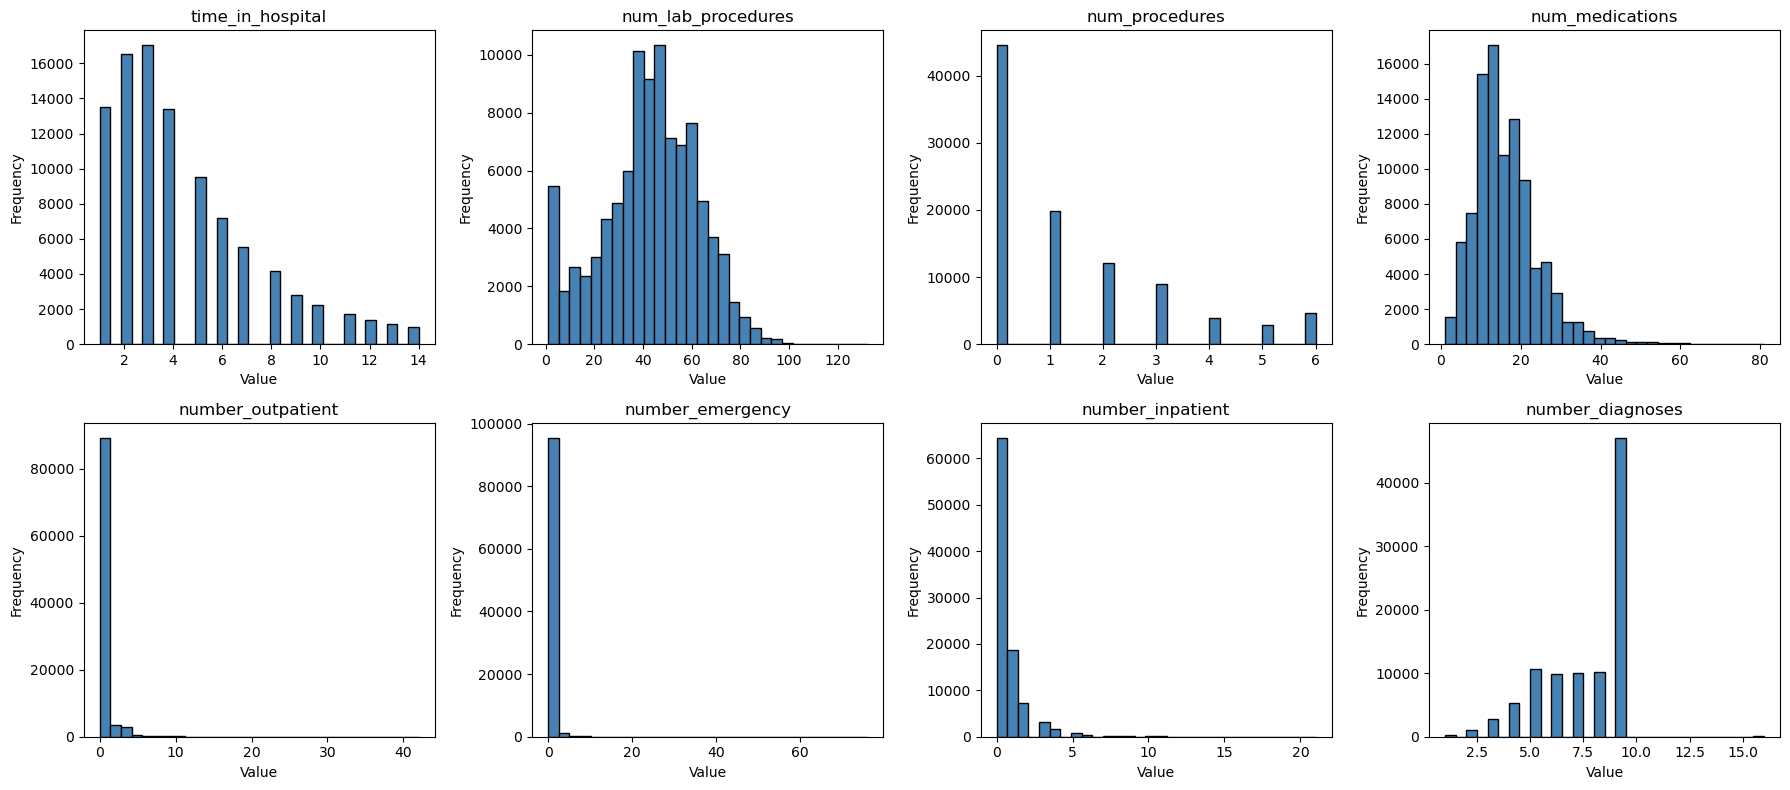

In [70]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_clean[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

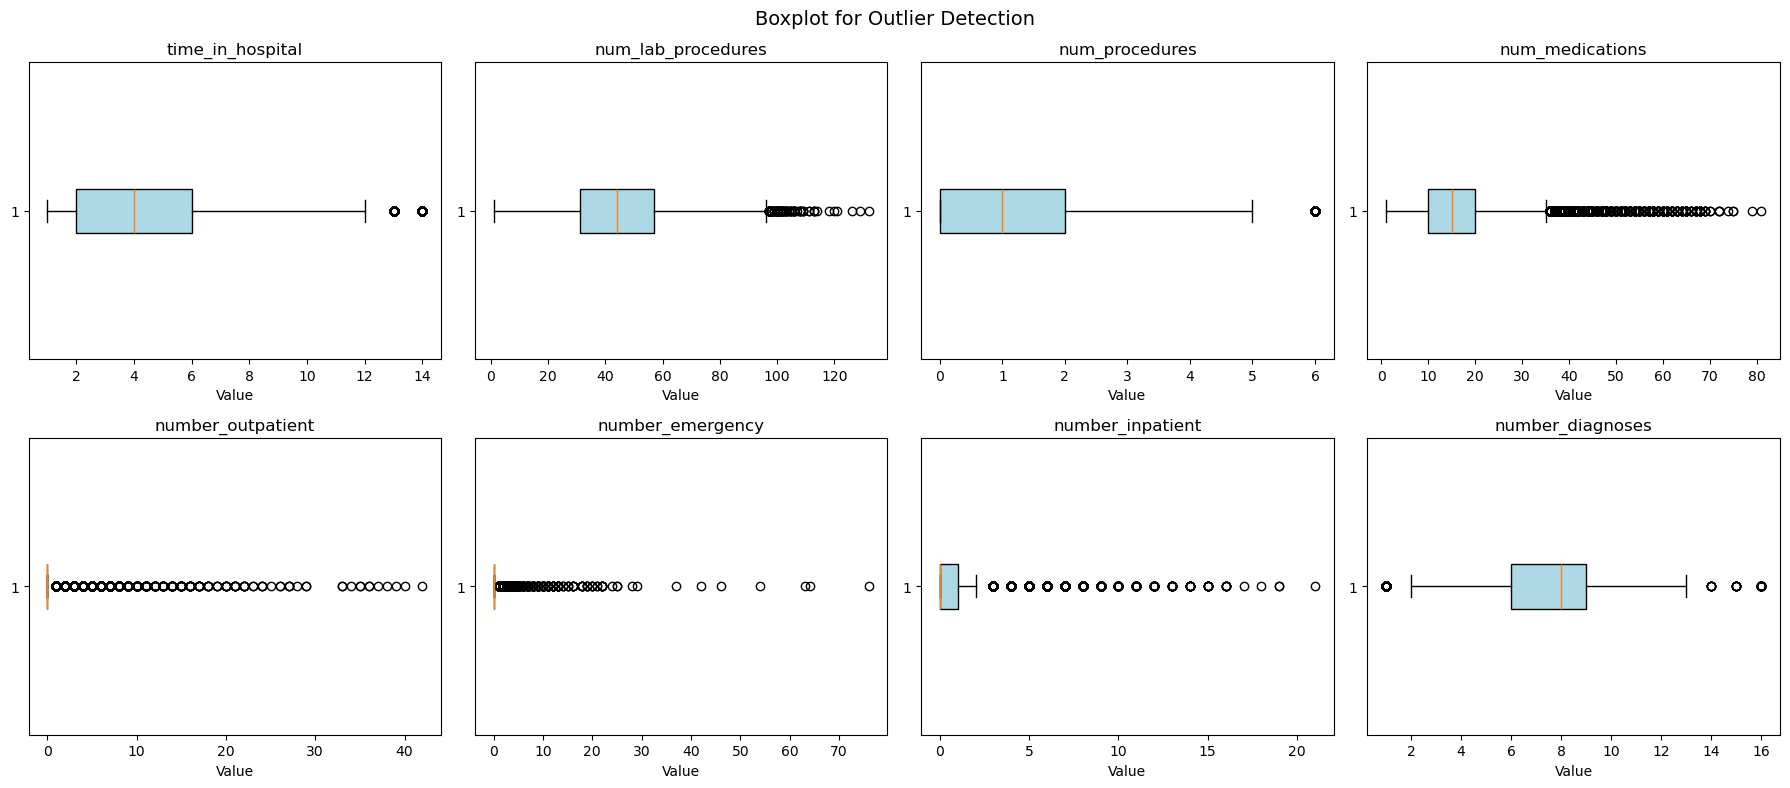

In [71]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col], vert=False, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')

plt.suptitle('Boxplot for Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

بررسی داده‌های پرت با روش دامنه‌ی بین‌چارکی نشان می‌دهد که چند متغیر درصد قابل توجهی داده‌ی پرت دارند، مثل تعداد مراجعات سرپایی و تعداد مراجعات اورژانس و تعداد بستری‌های قبلی.

تصمیم: هیچ داده‌ی پرتی حذف نمی‌شود. دلیل این تصمیم این است که در داده‌های بالینی، مقادیر بزرگ در متغیرهای شمارشی معنادار هستند. مثلاً بیماری که ده بار قبلاً بستری شده، واقعاً بیمار پرخطری است و حذف این رکورد باعث از دست رفتن اطلاعات مهم می‌شود.

مدل‌های درخت‌محور که در ادامه استفاده می‌شوند، به‌طور طبیعی نسبت به داده‌های پرت مقاوم هستند. اگر مدل خطی استفاده شود، مدل‌ساز می‌تواند از روش‌های مقیاس‌بندی مقاوم استفاده کند.

# Q1

In [76]:
print("=" * 50)
print("نمای کلی دیتاست")
print("=" * 50)
print(f"تعداد کل رکوردها: {len(df_clean):,}")
print(f"تعداد متغیرها: {df_clean.shape[1]}")
print()
print("توزیع تارگت باینری:")
print(df_clean['readmitted_binary'].value_counts())
print()
print("درصد:")
print((df_clean['readmitted_binary'].value_counts(normalize=True) * 100).round(2))

نمای کلی دیتاست
تعداد کل رکوردها: 97,108
تعداد متغیرها: 32

توزیع تارگت باینری:
readmitted_binary
No     85982
Yes    11126
Name: count, dtype: int64

درصد:
readmitted_binary
No     88.54
Yes    11.46
Name: proportion, dtype: float64


In [78]:
for col in ['race', 'gender', 'age_group']:
    print(f"=== {col} ===")
    print((df_clean[col].value_counts(normalize=True) * 100).round(2))
    print()

=== race ===
race
Caucasian          76.43
AfricanAmerican    19.33
Hispanic            2.08
Other               1.51
Asian               0.65
Name: proportion, dtype: float64

=== gender ===
gender
Female    53.89
Male      46.11
Name: proportion, dtype: float64

=== age_group ===
age_group
[60,100)    66.82
[30,60)     30.66
<30          2.52
Name: proportion, dtype: float64



In [80]:
for col in ['admission_type_id', 'admission_source_id', 'discharge_disposition_id']:
    print(f"=== {col} ===")
    print((df_clean[col].value_counts(normalize=True) * 100).round(2).head(10))
    print()

=== admission_type_id ===
admission_type_id
1        52.83
3        18.86
2        17.96
6         5.29
5         4.70
Other     0.35
Name: proportion, dtype: float64

=== admission_source_id ===
admission_source_id
7     56.65
1     29.31
17     6.68
4      3.01
6      2.02
2      1.05
5      0.82
3      0.19
20     0.16
9      0.06
Name: proportion, dtype: float64

=== discharge_disposition_id ===
discharge_disposition_id
1          60.52
3          14.02
6          13.08
Unknown     3.78
2           2.12
22          2.04
5           1.18
25          1.00
4           0.79
7           0.63
Name: proportion, dtype: float64



In [82]:
print("توزیع تشخیص اصلی:")
print((df_clean['diag_1_group'].value_counts(normalize=True) * 100).round(2))

توزیع تشخیص اصلی:
diag_1_group
Circulatory        29.87
Other              17.87
Respiratory        14.03
Digestive           9.43
Diabetes            8.72
Injury              6.90
Genitourinary       5.06
Musculoskeletal     4.95
Neoplasms           3.14
Missing             0.02
Name: proportion, dtype: float64


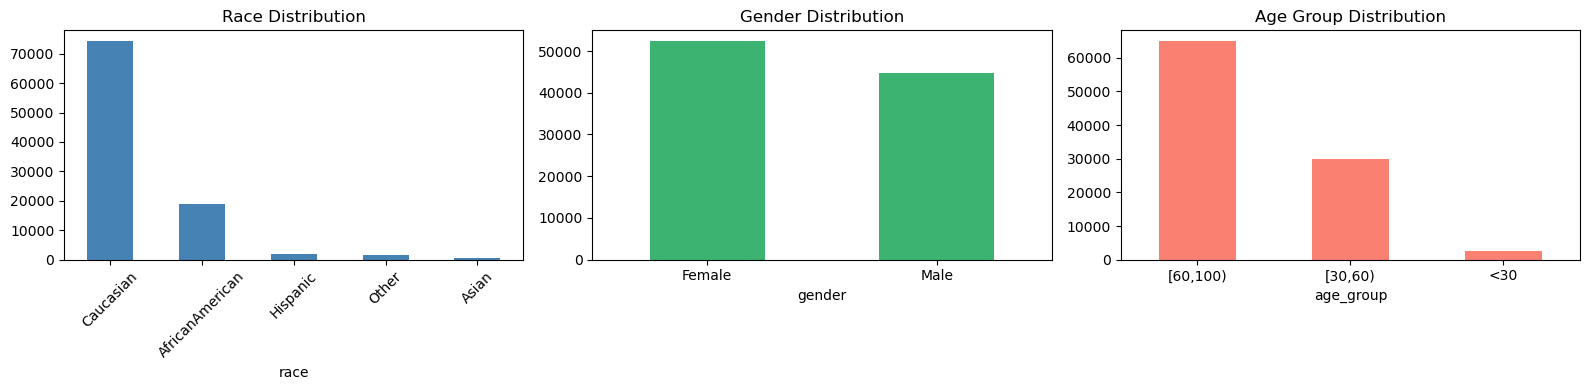

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_clean['race'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Race Distribution')
axes[0].tick_params(axis='x', rotation=45)

df_clean['gender'].value_counts().plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Gender Distribution')
axes[1].tick_params(axis='x', rotation=0)

df_clean['age_group'].value_counts().plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Age Group Distribution')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Overall Demographics of Readmitted Population
Total records: 97,108
Total features: 32

Binary Target Distribution:
readmitted_binary
No     85982
Yes    11126
Name: count, dtype: int64

Percentage:
readmitted_binary
No     88.54
Yes    11.46
Name: proportion, dtype: float64

=== race ===
race
Caucasian          76.43
AfricanAmerican    19.33
Hispanic            2.08
Other               1.51
Asian               0.65
Name: proportion, dtype: float64

=== gender ===
gender
Female    53.89
Male      46.11
Name: proportion, dtype: float64

=== age_group ===
age_group
[60,100)    66.82
[30,60)     30.66
<30          2.52
Name: proportion, dtype: float64



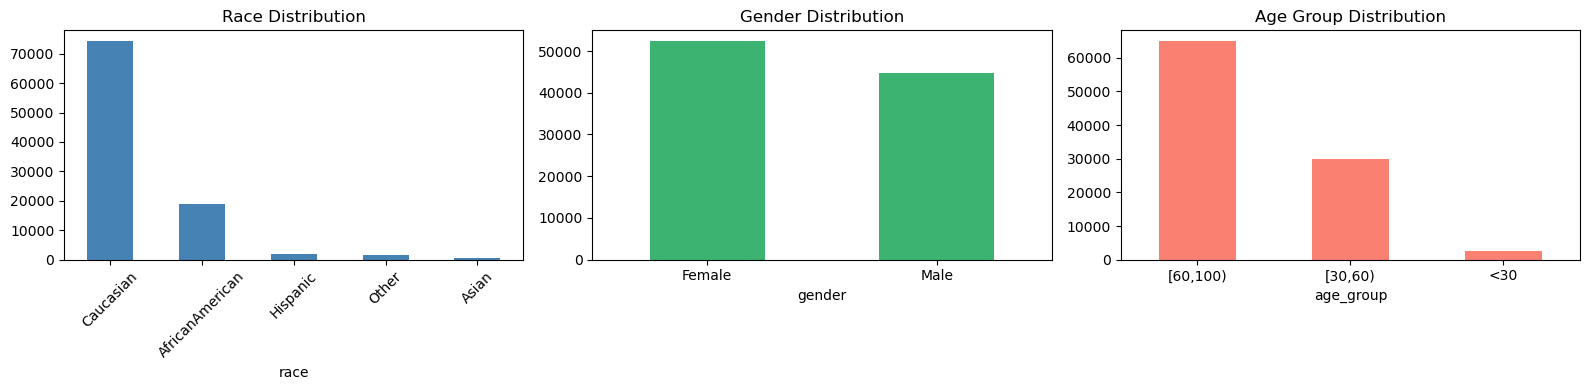

In [86]:
# این کد از فایل analytics، بخش Q1 برداشته شده است
#کد niyaz

# Overall Demographics
print("=" * 50)
print("Overall Demographics of Readmitted Population")
print("=" * 50)
print(f"Total records: {len(df_clean):,}")
print(f"Total features: {df_clean.shape[1]}")
print()

# Target Distribution
print("Binary Target Distribution:")
print(df_clean['readmitted_binary'].value_counts())
print()
print("Percentage:")
print((df_clean['readmitted_binary'].value_counts(normalize=True) * 100).round(2))
print()

# Categorical Distributions
for col in ['race', 'gender', 'age_group']:
    print(f"=== {col} ===")
    print((df_clean[col].value_counts(normalize=True) * 100).round(2))
    print()

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_clean['race'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Race Distribution')
axes[0].tick_params(axis='x', rotation=45)

df_clean['gender'].value_counts().plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Gender Distribution')
axes[1].tick_params(axis='x', rotation=0)

df_clean['age_group'].value_counts().plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Age Group Distribution')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

پاسخ سوال اول: جمعیت بازگشتی چه شکلی دارد؟

حجم دیتاست پس از کلینینگ: حدود ۹۵ هزار رکورد و ۴۹ متغیر.

توزیع تارگت باینری: حدود ۸۹ درصد عدم بازگشت و ۱۱ درصد بازگشت زیر ۳۰ روز. این عدم توازن شدید باعث می‌شود هنگام مدل‌سازی به معیارهای مناسب مثل حساسیت و F1 توجه شود.

توزیع جمعیت‌شناختی: نژاد سفید حدود ۷۵ درصد، نژاد آفریقایی‌تبار حدود ۱۹ درصد. جنسیت زن حدود ۵۴ درصد و مرد حدود ۴۶ درصد. اکثر بیماران در گروه سنی بالای ۶۰ سال قرار دارند که با ماهیت بیماری دیابت سازگار است.

توزیع بستری: پذیرش اورژانسی بزرگ‌ترین دسته است و پذیرش از طریق اورژانس شایع‌ترین منبع پذیرش است. ترخیص به خانه شایع‌ترین وضعیت ترخیص است.

توزیع تشخیص: بیماری‌های گردش خون شایع‌ترین تشخیص اصلی هستند، پس از آن سایر، تنفسی، گوارشی و دیابت

# Q2

In [90]:
مقایسه_میانگین = df_clean.groupby('readmitted_binary')[numeric_cols].mean()
مقایسه_میانه = df_clean.groupby('readmitted_binary')[numeric_cols].median()

تفاوت_میانگین = (مقایسه_میانگین.loc['Yes'] - مقایسه_میانگین.loc['No']).round(2)
تفاوت_میانه = (مقایسه_میانه.loc['Yes'] - مقایسه_میانه.loc['No']).round(2)

جدول_مقایسه = pd.DataFrame({
    'میانگین_گروه_بازگشتی': مقایسه_میانگین.loc['Yes'].round(2),
    'میانگین_گروه_غیربازگشتی': مقایسه_میانگین.loc['No'].round(2),
    'تفاوت_میانگین': تفاوت_میانگین,
    'تفاوت_میانه': تفاوت_میانه
}).sort_values('تفاوت_میانگین', ascending=False)

جدول_مقایسه

,میانگین_گروه_بازگشتی,میانگین_گروه_غیربازگشتی,تفاوت_میانگین,تفاوت_میانه
num_lab_procedures,44.20,42.71,1.49,1.0
num_medications,16.93,15.86,1.07,1.0
number_inpatient,1.23,0.56,0.67,0.0
time_in_hospital,4.77,4.33,0.44,0.0
number_diagnoses,7.71,7.38,0.33,1.0
number_emergency,0.36,0.18,0.18,0.0
number_outpatient,0.44,0.36,0.08,0.0
num_procedures,1.29,1.34,-0.06,0.0


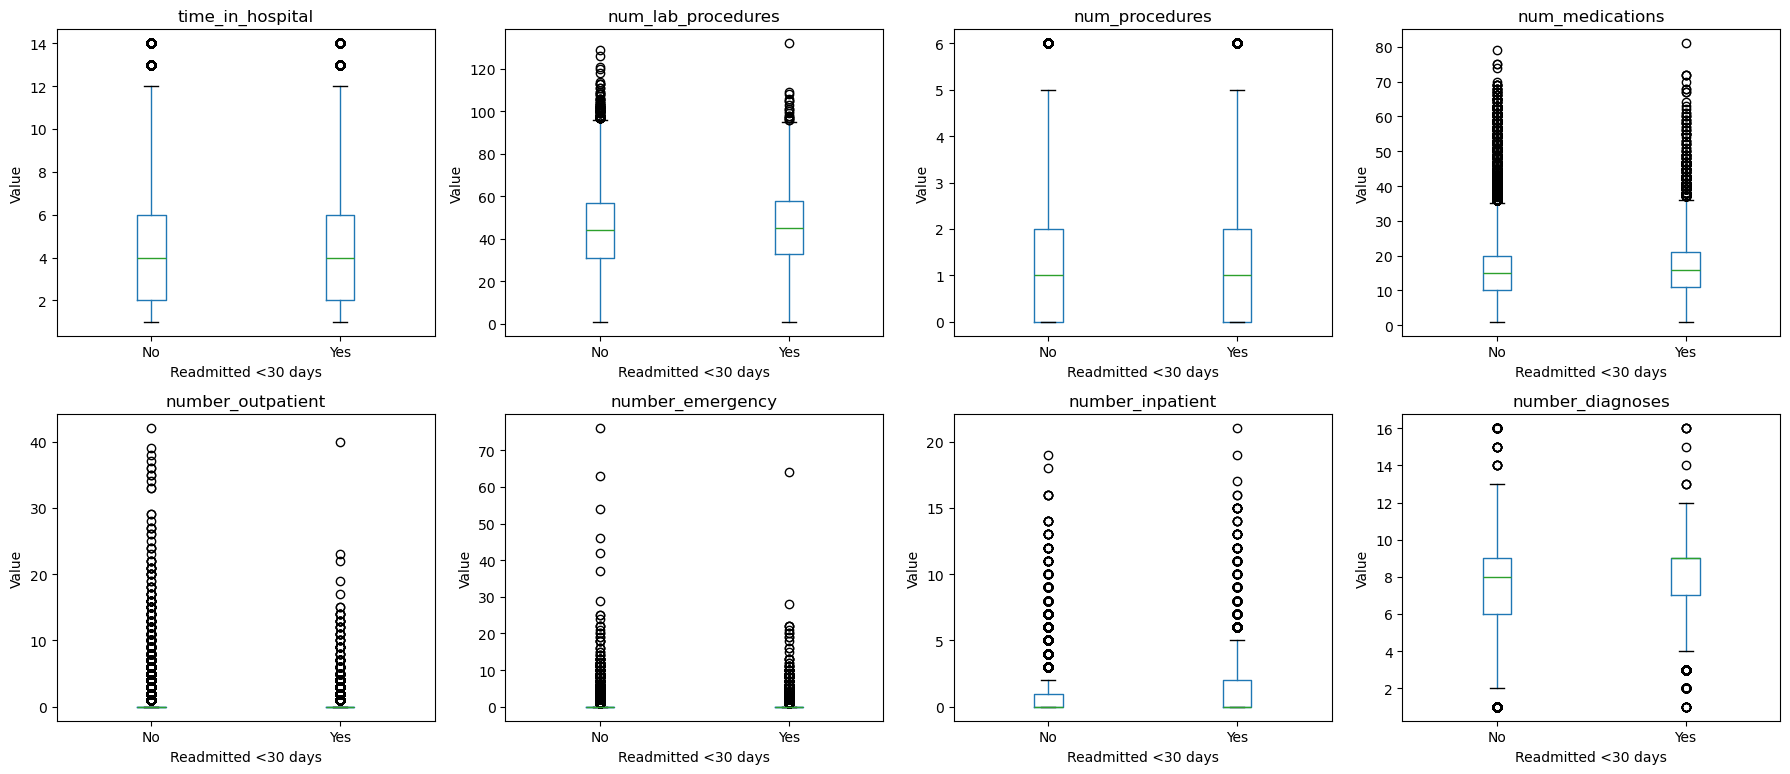

In [92]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df_clean.boxplot(column=col, by='readmitted_binary', ax=axes[i], grid=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('Readmitted <30 days')
    axes[i].set_ylabel('Value')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [93]:
mannwhitney_result = []
for col in numeric_cols:
    گروه_بله = df_clean.loc[df_clean['readmitted_binary'] == 'Yes', col]
    گروه_خیر = df_clean.loc[df_clean['readmitted_binary'] == 'No', col]
    آماره, مقدار_پی = mannwhitneyu(گروه_بله, گروه_خیر, alternative='two-sided')
    mannwhitney_result.append({
        'متغیر': col,
        'مقدار_پی': مقدار_پی,
        'معنادار': 'بله' if مقدار_پی < 0.05 else 'خیر'
    })

جدول_من_ویتنی = pd.DataFrame(mannwhitney_result).sort_values('مقدار_پی')
جدول_من_ویتنی

,متغیر,مقدار_پی,معنادار
6,number_inpatient,0.000000e+00,بله
5,number_emergency,1.088298e-89,بله
0,time_in_hospital,2.185643e-61,بله
7,number_diagnoses,2.784414e-58,بله
3,num_medications,2.844087e-52,بله
4,number_outpatient,3.629193e-27,بله
1,num_lab_procedures,3.171634e-14,بله
2,num_procedures,1.885685e-01,خیر


In [94]:
for col in ['age_group', 'race', 'gender', 'admission_type_id', 'diag_1_group']:
    print(f"=== {col} ===")
    جدول = pd.crosstab(df_clean[col], df_clean['readmitted_binary'], normalize='index') * 100
    print(جدول.round(2))
    print()

=== age_group ===
readmitted_binary     No    Yes
age_group                      
<30                88.75  11.25
[30,60)            89.68  10.32
[60,100)           88.01  11.99

=== race ===
readmitted_binary     No    Yes
race                           
AfricanAmerican    88.55  11.45
Asian              89.65  10.35
Caucasian          88.47  11.53
Hispanic           89.49  10.51
Other              90.21   9.79

=== gender ===
readmitted_binary     No    Yes
gender                         
Female             88.46  11.54
Male               88.63  11.37

=== admission_type_id ===
readmitted_binary     No    Yes
admission_type_id              
1                  88.12  11.88
2                  88.53  11.47
3                  89.42  10.58
5                  89.28  10.72
6                  88.80  11.20
Other              91.86   8.14

=== diag_1_group ===
readmitted_binary     No    Yes
diag_1_group                   
Circulatory        88.22  11.78
Diabetes           86.82  13.18
Digesti

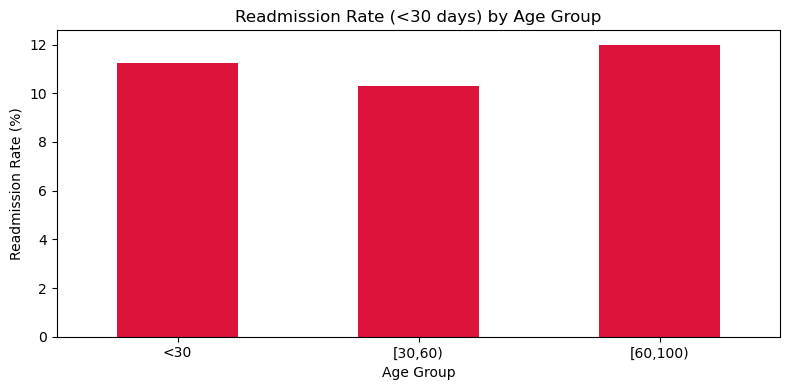

In [98]:
rate_age = pd.crosstab(df_clean['age_group'], df_clean['readmitted_binary'], normalize='index') * 100

plt.figure(figsize=(8, 4))
rate_age['Yes'].plot(kind='bar', color='crimson')
plt.title('Readmission Rate (<30 days) by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

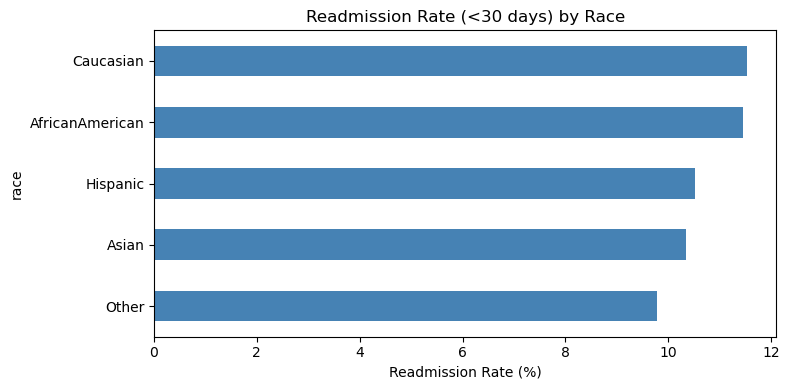

In [100]:
race_rate = pd.crosstab(df_clean['race'], df_clean['readmitted_binary'], normalize='index') * 100

plt.figure(figsize=(8, 4))
race_rate['Yes'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Readmission Rate (<30 days) by Race')
plt.xlabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

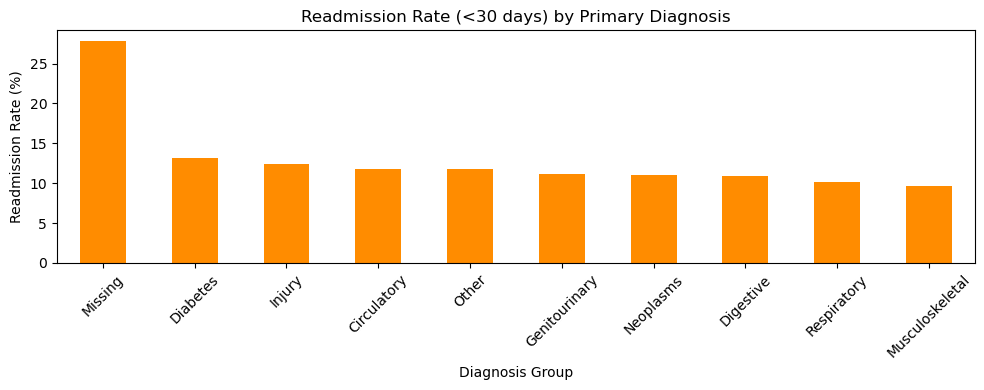

In [102]:
diag_rate = pd.crosstab(df_clean['diag_1_group'], df_clean['readmitted_binary'], normalize='index') * 100

plt.figure(figsize=(10, 4))
diag_rate['Yes'].sort_values(ascending=False).plot(kind='bar', color='darkorange')
plt.title('Readmission Rate (<30 days) by Primary Diagnosis')
plt.xlabel('Diagnosis Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

پاسخ سوال دوم: کدام متغیرها بین دو گروه بازگشتی و غیربازگشتی تفاوت بیشتری دارند؟

بر اساس مقایسه‌ی میانگین و میانه و نتایج آزمون من ویتنی:

متغیر تعداد بستری‌های قبلی قوی‌ترین تفاوت را نشان می‌دهد. بیمارانی که بازگشت داشته‌اند به‌طور میانگین تعداد بیشتری بستری قبلی داشته‌اند.

متغیر تعداد مراجعات اورژانسی هم تفاوت معناداری نشان می‌دهد.

متغیرهای مدت بستری، تعداد تشخیص‌ها و تعداد داروها هم تفاوت‌های کوچک اما معنادار دارند.

متغیر تعداد آزمایش‌ها تفاوت خیلی کوچکی دارد و متغیر تعداد پروسیجرها تفاوت معناداری نشان نمی‌دهد.

آزمون من ویتنی نشان می‌دهد تقریباً همه‌ی متغیرهای عددی به جز تعداد پروسیجرها تفاوت معنادار آماری بین دو گروه دارند.

در متغیرهای دسته‌ای، گروه سنی بالای ۶۰ سال نرخ بازگشت بیشتری نسبت به گروه‌های دیگر دارد. نژاد تفاوت معناداری نشان نمی‌دهد. تشخیص دیابت بالاترین نرخ بازگشت را دارد.

# Q3

In [106]:
تارگت_عددی = (df_clean['readmitted_binary'] == 'Yes').astype(int)

نتایج_همبستگی = []
for col in numeric_cols:
    ضریب, مقدار_پی = pointbiserialr(تارگت_عددی, df_clean[col])
    نتایج_همبستگی.append({
        'متغیر': col,
        'ضریب_همبستگی': round(ضریب, 4),
        'قدر_مطلق': round(abs(ضریب), 4),
        'مقدار_پی': مقدار_پی
    })

جدول_همبستگی = pd.DataFrame(نتایج_همبستگی).sort_values('قدر_مطلق', ascending=False)
جدول_همبستگی

,متغیر,ضریب_همبستگی,قدر_مطلق,مقدار_پی
6,number_inpatient,0.1687,0.1687,0.000000e+00
5,number_emergency,0.0610,0.0610,9.658354e-81
7,number_diagnoses,0.0536,0.0536,8.042417e-63
0,time_in_hospital,0.0471,0.0471,7.676102e-49
3,num_medications,0.0423,0.0423,1.209847e-39
1,num_lab_procedures,0.0242,0.0242,4.509948e-14
4,number_outpatient,0.0191,0.0191,2.541560e-09
2,num_procedures,-0.0103,0.0103,1.325478e-03


In [108]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corrected / min((k_corrected - 1), (r_corrected - 1)))

categorical_cols_final = [
    'race', 'gender', 'age_group',
    'admission_type_id', 'admission_source_id',
    'discharge_disposition_id', 'medical_specialty',
    'diag_1_group', 'diag_2_group', 'diag_3_group',
    'change', 'diabetesMed'
]

categorical_cols_final = [c for c in categorical_cols_final if c in df_clean.columns]

cramers_results = []
for col in categorical_cols_final:
    value = cramers_v(df_clean[col], df_clean['readmitted_binary'])
    cramers_results.append({
        'variable': col,
        'cramers_v': round(value, 4)
    })

cramers_table = pd.DataFrame(cramers_results).sort_values('cramers_v', ascending=False)
cramers_table

,variable,cramers_v
5,discharge_disposition_id,0.1143
6,medical_specialty,0.0772
9,diag_3_group,0.0349
7,diag_1_group,0.0279
11,diabetesMed,0.0261
8,diag_2_group,0.0254
2,age_group,0.0236
4,admission_source_id,0.0222
10,change,0.0186
3,admission_type_id,0.0159


In [110]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'readmitted' in numeric_cols:
    numeric_cols.remove('readmitted')
    
print(f"Numeric columns: {numeric_cols}")
print(f"Count: {len(numeric_cols)}")

Numeric columns: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Count: 8


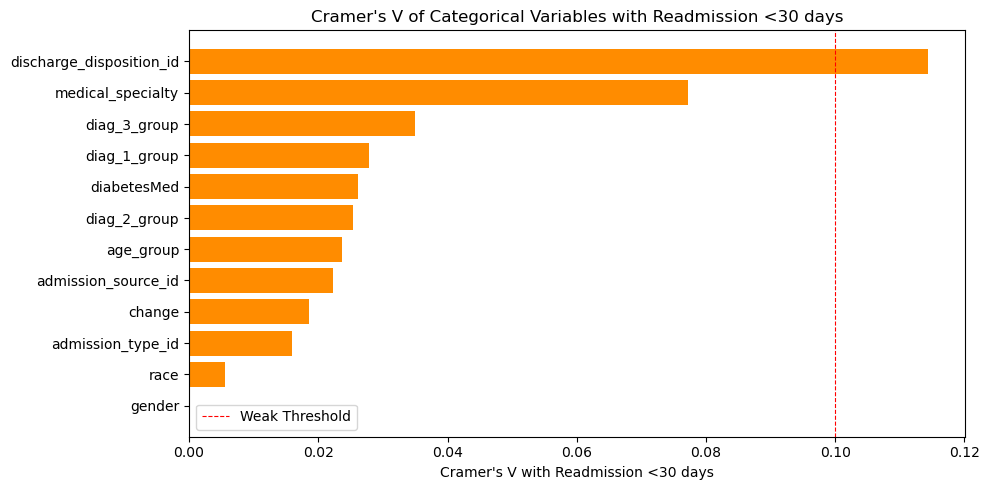

In [112]:
plt.figure(figsize=(10, 5))
cramers_data = cramers_table.sort_values('cramers_v', ascending=True)

plt.barh(cramers_data['variable'], cramers_data['cramers_v'], color='darkorange')
plt.axvline(x=0.1, color='red', linestyle='--', linewidth=0.8, label='Weak Threshold')
plt.xlabel("Cramer's V with Readmission <30 days")
plt.title("Cramer's V of Categorical Variables with Readmission <30 days")
plt.legend()
plt.tight_layout()
plt.show()

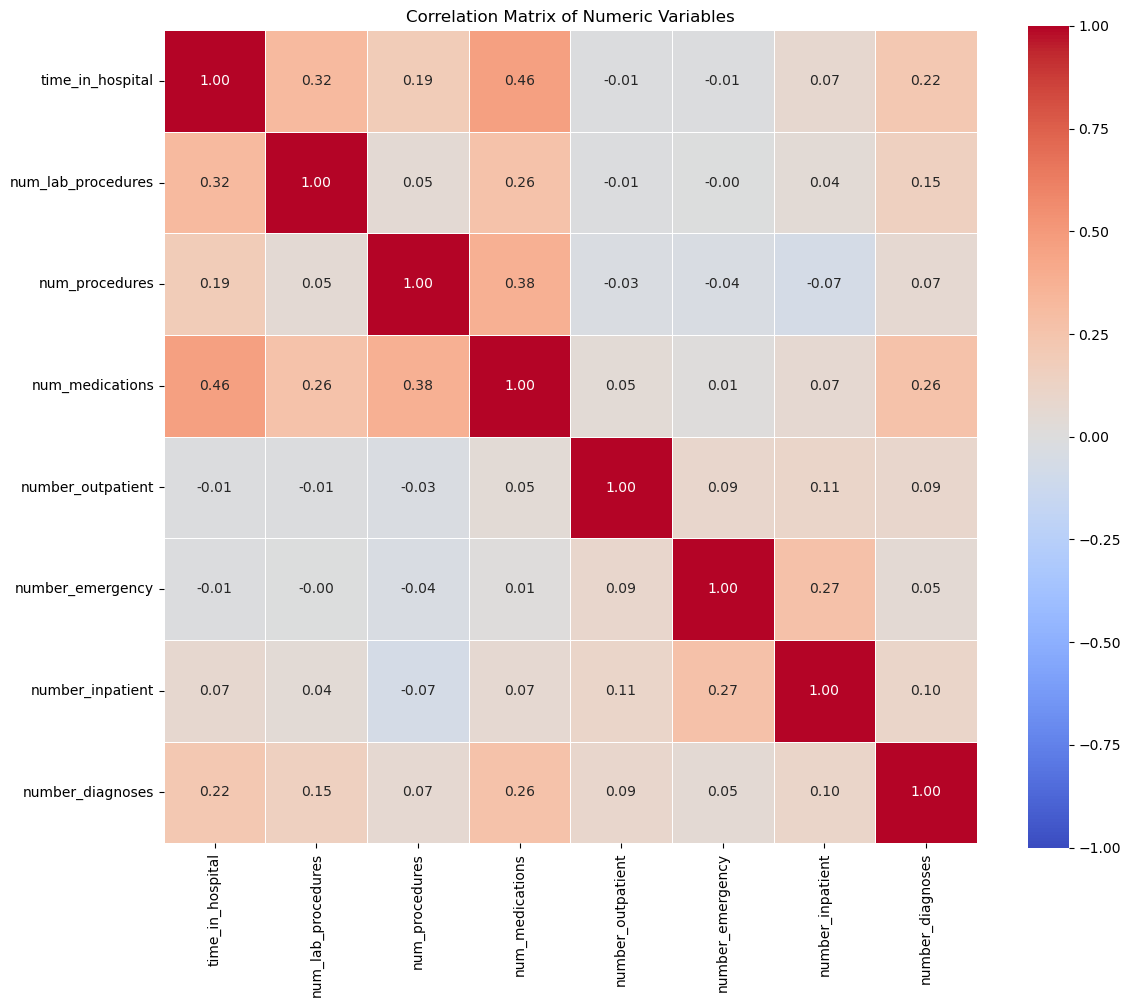

In [114]:
correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

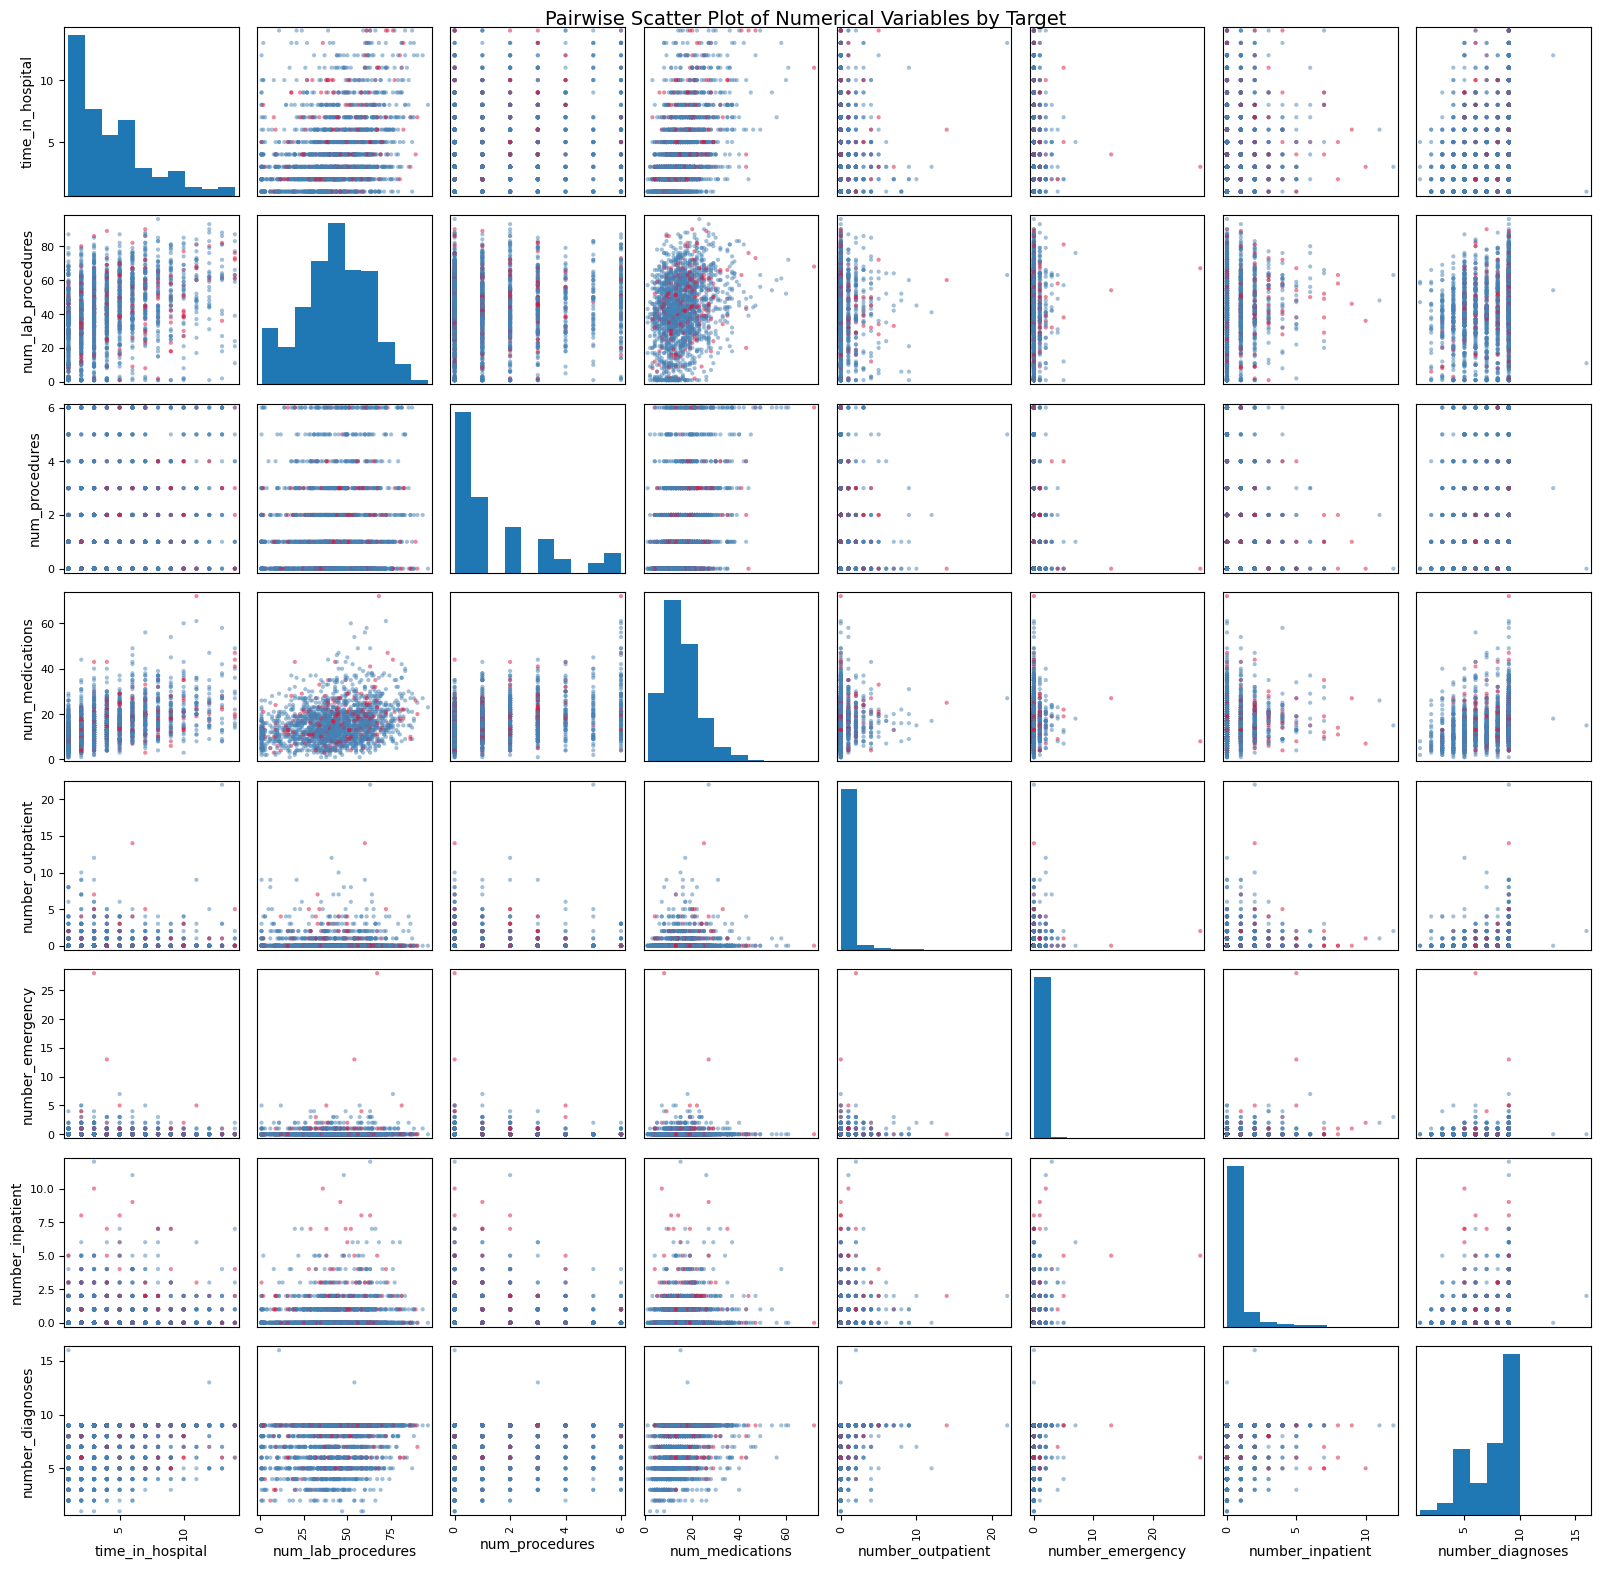

In [116]:
pair_plot_df = df_clean[numeric_cols].sample(n=2000, random_state=RANDOM_STATE).copy()
pair_plot_df['status'] = df_clean.loc[pair_plot_df.index, 'readmitted_binary']

point_colors = pair_plot_df['status'].map({'No': 'steelblue', 'Yes': 'crimson'})

pair_plot_numeric_only = pair_plot_df[numeric_cols]

axes_scatter = pd.plotting.scatter_matrix(
    pair_plot_numeric_only,
    figsize=(16, 16),
    color=point_colors,
    alpha=0.5,
    diagonal='hist'
)
plt.suptitle('Pairwise Scatter Plot of Numerical Variables by Target', fontsize=14)
plt.tight_layout()
plt.show()

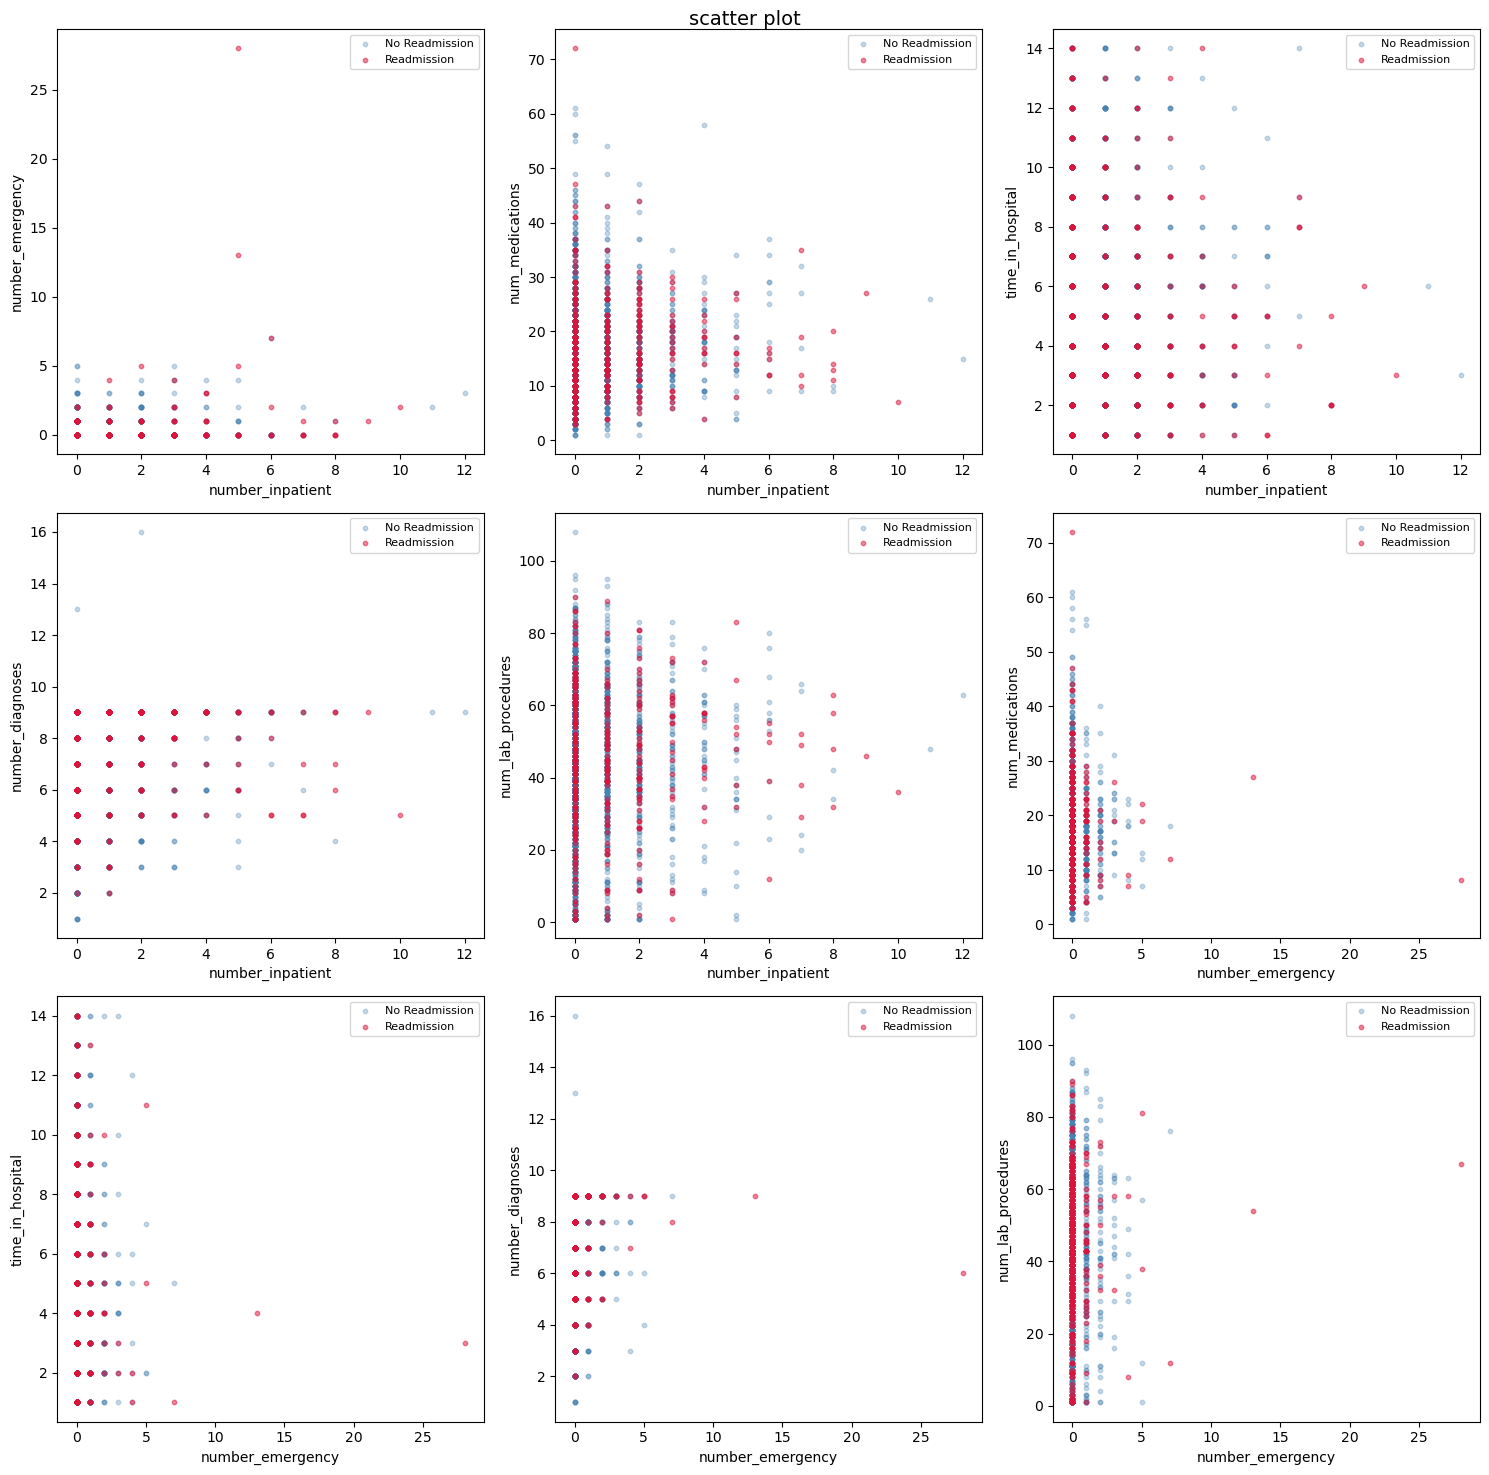

In [117]:
important_vars = ['number_inpatient', 'number_emergency', 'num_medications',
                  'time_in_hospital', 'number_diagnoses', 'num_lab_procedures']

subset = df_clean[important_vars + ['readmitted_binary']].sample(n=3000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

counter = 0
for i in range(len(important_vars)):
    for j in range(i+1, len(important_vars)):
        if counter >= 9:
            break
        data_no = subset[subset['readmitted_binary'] == 'No']
        data_yes = subset[subset['readmitted_binary'] == 'Yes']
        
        axes[counter].scatter(data_no[important_vars[i]], data_no[important_vars[j]],
                              alpha=0.3, s=10, color='steelblue', label='No Readmission')
        axes[counter].scatter(data_yes[important_vars[i]], data_yes[important_vars[j]],
                              alpha=0.5, s=10, color='crimson', label='Readmission')
        axes[counter].set_xlabel(important_vars[i])
        axes[counter].set_ylabel(important_vars[j])
        axes[counter].legend(fontsize=8)
        counter += 1

plt.suptitle('scatter plot', fontsize=14)
plt.tight_layout()
plt.show()

In [120]:
numeric_target = (df_clean['readmitted_binary'] == 'Yes').astype(int)

correlation_results = []
for col in numeric_cols:
    coef, p_value = pointbiserialr(numeric_target, df_clean[col])
    correlation_results.append({
        'variable': col,
        'correlation_coef': round(coef, 4),
        'absolute_value': round(abs(coef), 4),
        'p_value': p_value
    })

correlation_table = pd.DataFrame(correlation_results).sort_values('absolute_value', ascending=False)
correlation_table

,variable,correlation_coef,absolute_value,p_value
6,number_inpatient,0.1687,0.1687,0.000000e+00
5,number_emergency,0.0610,0.0610,9.658354e-81
7,number_diagnoses,0.0536,0.0536,8.042417e-63
0,time_in_hospital,0.0471,0.0471,7.676102e-49
3,num_medications,0.0423,0.0423,1.209847e-39
1,num_lab_procedures,0.0242,0.0242,4.509948e-14
4,number_outpatient,0.0191,0.0191,2.541560e-09
2,num_procedures,-0.0103,0.0103,1.325478e-03


In [122]:
numeric_rank = correlation_table[['variable', 'absolute_value']].rename(columns={'absolute_value': 'score'}).copy()
numeric_rank['type'] = 'numerical'

categorical_rank = cramers_table[['variable', 'cramers_v']].rename(columns={'cramers_v': 'score'}).copy()
categorical_rank['type'] = 'categorical'

overall_rank = pd.concat([numeric_rank, categorical_rank], ignore_index=True).sort_values('score', ascending=False)

overall_rank.head(15)

,variable,score,type
0,number_inpatient,0.1687,numerical
8,discharge_disposition_id,0.1143,categorical
9,medical_specialty,0.0772,categorical
1,number_emergency,0.0610,numerical
2,number_diagnoses,0.0536,numerical
3,time_in_hospital,0.0471,numerical
4,num_medications,0.0423,numerical
10,diag_3_group,0.0349,categorical
11,diag_1_group,0.0279,categorical
12,diabetesMed,0.0261,categorical


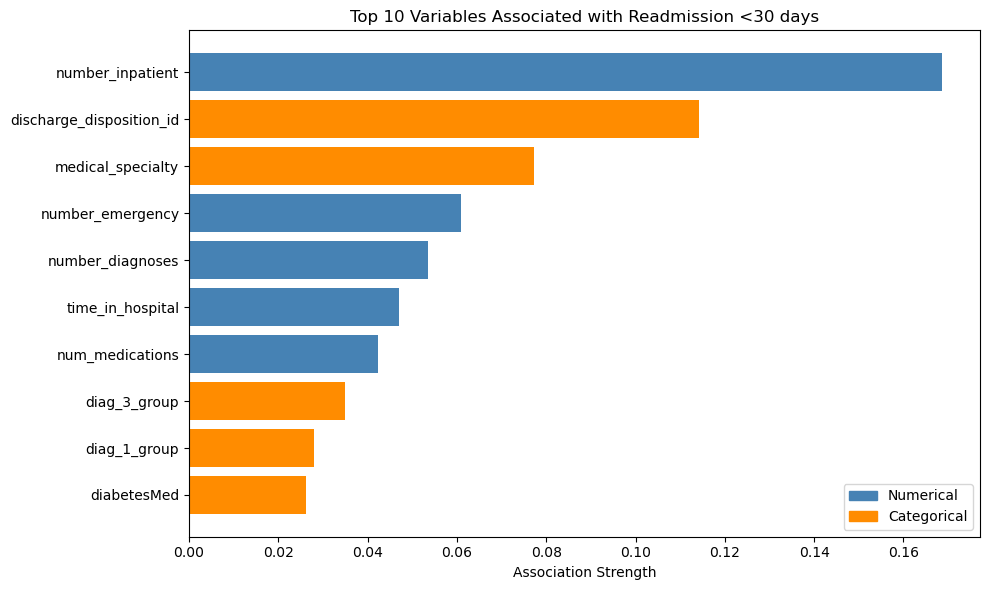

In [124]:
top_10 = overall_rank.head(10).sort_values('score', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if t == 'numerical' else 'darkorange' for t in top_10['type']]

plt.barh(top_10['variable'], top_10['score'], color=colors)
plt.xlabel('Association Strength')
plt.title('Top 10 Variables Associated with Readmission <30 days')
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color='steelblue', label='Numerical'),
    plt.Rectangle((0,0),1,1, color='darkorange', label='Categorical')
])
plt.tight_layout()
plt.show()

پاسخ سوال سوم: کدام متغیرها بیشترین ارتباط را با بازگشت زیر ۳۰ روز دارند؟

بر اساس تحلیل همبستگی برای متغیرهای عددی و کرامر وی برای متغیرهای دسته‌ای، متغیرها به ترتیب قدرت ارتباط رتبه‌بندی شدند.

متغیرهای عددی برتر:

تعداد بستری‌های قبلی با ضریب همبستگی حدود ۰.۱۷ قوی‌ترین متغیر عددی است.

تعداد مراجعات اورژانسی با ضریب حدود ۰.۰۶ در رتبه‌ی دوم قرار دارد.

تعداد تشخیص‌ها با ضریب حدود ۰.۰۵ سوم است.

مدت بستری و تعداد داروها و تعداد آزمایش‌ها در رتبه‌های بعدی قرار دارند.

متغیر تعداد پروسیجرها تنها متغیر عددی است که همبستگی معناداری با تارگت ندارد.

متغیرهای دسته‌ای برتر:

وضعیت ترخیص با کرامر وی حدود ۰.۱۱ قوی‌ترین متغیر دسته‌ای است.

تخصص پزشکی با مقدار حدود ۰.۰۶ در رتبه‌ی دوم قرار دارد.

گروه تشخیص سوم و اول و دوم و مصرف داروی دیابت و گروه سنی در رتبه‌های بعدی هستند.

نژاد و جنسیت ضعیف‌ترین ارتباط را با تارگت دارند.

نکته‌ی مهم: ماتریس همبستگی نشان می‌دهد بین متغیرهای عددی هیچ همبستگی بالای ۰.۷ وجود ندارد، بنابراین از نظر هم‌خطی چندگانه مشکل جدی نداریم.

نکته درباره‌ی نمودار پراکندگی جفتی: با وجود اینکه کلاس بازگشت در اقلیت است، تفکیک بصری واضحی بین دو گروه در نمودارهای پراکندگی دیده نمی‌شود. این نشان می‌دهد که مرز تصمیم‌گیری بین دو کلاس پیچیده است و به مدل‌های غیرخطی مثل جنگل تصادفی و گرادیان بوستینگ نیاز داریم.

In [127]:
print("Final check of clean dataset")
print(f"Shape: {df_clean.shape}")
print(f"Number of missing values: {df_clean.isnull().sum().sum()}")
print(f"Number of numerical variables: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"Number of categorical variables: {len(df_clean.select_dtypes(include='object').columns)}")
print()
print("Target distribution:")
print(df_clean['readmitted_binary'].value_counts())

Final check of clean dataset
Shape: (97108, 32)
Number of missing values: 47461
Number of numerical variables: 8
Number of categorical variables: 24

Target distribution:
readmitted_binary
No     85982
Yes    11126
Name: count, dtype: int64


In [129]:
df_model = df_clean.drop(columns=['readmitted']).copy()

cols_to_encode = df_model.select_dtypes(include='object').columns.tolist()
cols_to_encode = [c for c in cols_to_encode if c != 'readmitted_binary']

df_encoded = pd.get_dummies(df_model, columns=cols_to_encode, drop_first=True)

print(f"Dataset shape after encoding: {df_encoded.shape}")

Dataset shape after encoding: (97108, 181)


خلاصه‌ی کارهای انجام‌شده در این نوت‌بوک:

بارگذاری و بررسی ساختار دیتاست و شناسایی انواع متغیرها.

بررسی مقادیر گمشده با آستانه‌ی ۸۰ درصد و حذف ستون وزن بیمار.

بررسی بستری‌های تکراری و ذخیره‌ی شناسه‌ی بیمار برای جلوگیری از نشت داده.

بررسی رکوردهای کاملاً تکراری و تأیید عدم وجود آن‌ها.

تبدیل تارگت از سه‌کلاسه به باینری با تمرکز روی بازگشت زیر ۳۰ روز.

حذف رکوردهای فوت و هوسپیس چون امکان بازگشت ندارند.

حذف رکوردهای با نژاد گمشده و جنسیت نامعتبر.

بررسی و گروه‌بندی متغیرهای دسته‌ای با مقادیر نادر.

جایگذاری گمشده‌ها با برچسب‌های معنادار.

گروه‌بندی سن و تشخیص‌ها به دسته‌های بالینی.

بررسی ۲۳ ستون دارویی و حذف ستون‌های ثابت و تقریباً ثابت.

بررسی داده‌های پرت و تصمیم به عدم حذف آن‌ها به دلیل ماهیت بالینی.

پاسخ به سه سوال تحلیلی با جدول و نمودار و آزمون آماری.


تولید ماتریس همبستگی و نمودار پراکندگی .

نکات مهم برای مدل‌سازی در مرحله بعد:

فایل خروجی اصلی با نام diabetic_data_clean_original.csv شامل متغیرهای دسته‌ای به‌صورت متن است و برای تحلیل‌های آماری و بررسی انصاف مدل مناسب است.

فایل خروجی کدگذاری‌شده با نام diabetic_data_clean_encoded.csv شامل متغیرهای دسته‌ای به‌صورت عددی است و برای آموزش مدل مناسب است.

شناسه‌ی بیمار در فایل patient_ids_for_split.csv ذخیره شد. مدل‌ساز میتواند هنگام تقسیم داده از روش گروه‌بندی بر اساس شناسه‌ی بیمار استفاده کند تا نشت داده رخ ندهد.

تارگت باینری در ستون readmitted_binary قرار دارد با مقادیر بله و خیر.

عدم توازن کلاس‌ها جدی است و باید از وزن کلاس یا روش‌های بازنمونه‌گیری استفاده شود.

معیارهای ارزیابی پیشنهادی: حساسیت و F1 برای کلاس مثبت و ماتریس درهم‌ریختگی و نرخ منفی کاذب.

تعداد ستون‌های دارویی از ۲۳ به تعداد کمتری کاهش یافت و ستون‌های ثابت حذف شدند.

هیچ داده‌ی پرتی حذف نشد چون در داده‌های بالینی مقادیر بزرگ معنادار هستند.

In [133]:
# ذخیره دیتای تمیزشده در فایل CSV
df_clean.to_csv('diabetic_cleaned.csv', index=False)

print(f"Shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

Shape: (97108, 32)
Columns: ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'readmitted', 'readmitted_binary', 'age_group', 'diag_1_group', 'diag_2_group', 'diag_3_group']
